# Phase 3: GradCAM Validation

In this notebook, we visually validate the GradCAM heatmaps.
We will load the trained EfficientNet-B4 model, select sample MRI slices, and generate heatmaps overlaying the original image to ensure it highlights critical regions (like the hippocampus and entorhinal cortex) in positive cases.

In [2]:
import os
import sys
import torch
import matplotlib.pyplot as plt
from PIL import Image
import random

# Add the parent directory to sys.path to import backend modules
sys.path.append(os.path.abspath('..'))

from backend.core.model import get_model
from backend.core.preprocessing import get_dataloaders, get_transforms
from backend.core.gradcam import generate_heatmap

## 1. Load the Trained Model

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load model architecture
model = get_model(num_classes=4, pretrained=False)

# Load trained weights
weights_path = '../backend/models/efficientnet_adni.pth'
if os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print("Trained weights loaded successfully.")
else:
    print("Warning: Trained weights not found. Using untrained model for testing.")

model = model.to(device)
model.eval() # Ensure model is in evaluation mode

Using device: cpu
Trained weights loaded successfully.


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
            (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

## 2. Load Sample Images

In [4]:
DATASET_DIR = "../dataset/Alzheimer_Dataset_V3/Unaugmented"
_, val_test_transform = get_transforms()

# Define inverse class mapping to display text labels
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

def get_random_sample(cls_name):
    cls_dir = os.path.join(DATASET_DIR, cls_name)
    files = [f for f in os.listdir(cls_dir) if f.endswith('.jpg')]
    random_file = random.choice(files)
    return os.path.join(cls_dir, random_file)

# Pick one sample from each class
samples = {cls: get_random_sample(cls) for cls in class_names}

## 3. Generate and Visualize Heatmaps

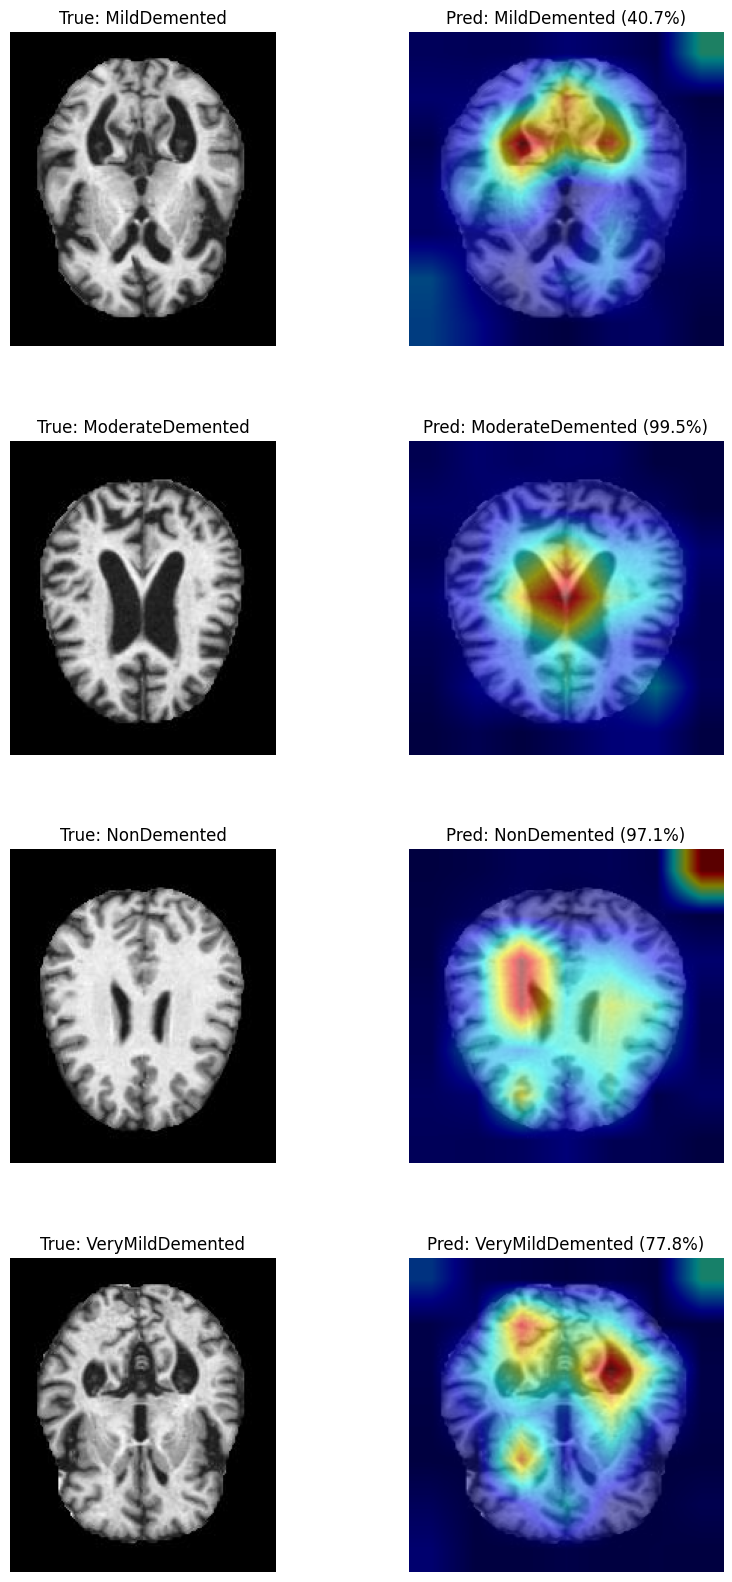

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(10, 20))
plt.subplots_adjust(hspace=0.3)

for i, (cls_name, img_path) in enumerate(samples.items()):
    # Load original image
    orig_img = Image.open(img_path).convert('RGB')
    
    # Preprocess tensor
    input_tensor = val_test_transform(orig_img).unsqueeze(0).to(device)
    
    # Get prediction
    with torch.no_grad():
        output = model(input_tensor)
        pred_idx = torch.argmax(output, 1).item()
        pred_class = idx_to_class[pred_idx]
        confidence = torch.softmax(output, 1)[0][pred_idx].item()
        
    # Generate Heatmap (using the predicted class as target)
    # We specify target_class=None so pytorch-grad-cam uses the model's highest scoring class
    heatmap_img = generate_heatmap(model, input_tensor, orig_img, target_class=None)
    
    # Plot Original
    axes[i, 0].imshow(orig_img, cmap='gray')
    axes[i, 0].set_title(f"True: {cls_name}")
    axes[i, 0].axis('off')
    
    # Plot Heatmap Overlay
    axes[i, 1].imshow(heatmap_img)
    axes[i, 1].set_title(f"Pred: {pred_class} ({confidence*100:.1f}%)")
    axes[i, 1].axis('off')

plt.show()